# Notebook 01: Data Intake, Audit, and Source Feasibility

## Academic Introduction

This project studies auditor-switch events among Israeli public companies. The motivating research question is whether the stock market exhibits a measurable reaction around the date on which a company changes its external auditor, with particular attention to switches from a Big-4 auditor to a non-Big-4 auditor, and from a non-Big-4 auditor to a Big-4 auditor.

An event-study framework is appropriate because auditor changes may convey information about perceived audit quality, reporting credibility, governance, cost considerations, or firm-specific uncertainty. In later notebooks, the empirical design will compare returns around the auditor-switch event window with an appropriate benchmark, such as a market-adjusted return. At this stage, however, the analysis is limited to data preparation and source feasibility.

Notebook 01 therefore builds a clean research dataset from the raw Excel file, flags data-quality limitations, derives preliminary event variables, and prepares the source layer required for future price extraction. It does not estimate abnormal returns, it does not perform the final event-study calculation, and it does not make causal claims. Any patterns observed here should be interpreted only as preliminary indications about data availability and research readiness.

## How this notebook supports the final dashboard

The final academic submission for this project is the Streamlit dashboard. The notebooks are the research and data-engineering pipeline that prepares clean, documented, and reproducible artifacts for that dashboard.

Notebook 01 creates the event-level dataset that the dashboard will later load as its base table. To support that use case, the cleaned outputs are saved in stable dashboard-ready formats under `data/interim/` and `data/output/`, with canonical column names such as `company_name`, `event_date`, `event_year`, `event_month`, `from_big4`, `to_big4`, `switch_type`, `data_status`, and `price_consistency_flag`.

Later notebooks will enrich this cleaned event table with ticker mapping, historical stock prices, TA-125 prices, event-window prices, stock returns, market returns, and market-adjusted returns. The dashboard should eventually consume those notebook-generated artifacts rather than redoing raw data cleaning inside the app.

## 1. Imports and Configuration

The notebook uses standard data-analysis libraries and local helper modules. Paths are defined relative to the project root so the workflow can be rerun on another machine without hard-coded absolute paths.

In [22]:
import json
import re
import sys
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("default")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.load_events import (
    build_dataframe_from_header,
    choose_data_sheet,
    choose_excel_file,
    detect_header_row,
    load_excel_sheets,
    normalize_event_columns,
)
from src.data_quality import (
    add_clean_fields,
    add_price_consistency,
    assign_data_status,
    build_data_quality_summary,
    build_data_quality_table,
    save_quality_json,
)
from src.source_feasibility import build_source_feasibility_df, run_connectivity_tests
from src.utils import ensure_directories

DATA_INPUT_DIR = PROJECT_ROOT / "data" / "input"
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
CACHE_DIR = PROJECT_ROOT / "data" / "cache"
SOURCE_TEST_DIR = CACHE_DIR / "source_tests"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT

WindowsPath('C:/Users/Guy/Desktop/Tene')

## 2. Folder Setup

The analysis writes intermediate datasets, final audit reports, cache files, and figures to separate folders. Creating these folders explicitly supports reproducibility and makes later notebooks less dependent on manual setup.

In [23]:
required_dirs = [
    DATA_INPUT_DIR,
    DATA_INTERIM_DIR,
    DATA_OUTPUT_DIR,
    CACHE_DIR,
    CACHE_DIR / "prices",
    SOURCE_TEST_DIR,
    FIGURES_DIR,
]
ensure_directories(required_dirs)
required_dirs

[WindowsPath('C:/Users/Guy/Desktop/Tene/data/input'),
 WindowsPath('C:/Users/Guy/Desktop/Tene/data/interim'),
 WindowsPath('C:/Users/Guy/Desktop/Tene/data/output'),
 WindowsPath('C:/Users/Guy/Desktop/Tene/data/cache'),
 WindowsPath('C:/Users/Guy/Desktop/Tene/data/cache/prices'),
 WindowsPath('C:/Users/Guy/Desktop/Tene/data/cache/source_tests'),
 WindowsPath('C:/Users/Guy/Desktop/Tene/reports/figures')]

## 3. Raw Excel Discovery and Loading

The raw file may contain Hebrew column names, nonstandard header placement, Excel error cells, and multiple sheets. The workflow first loads all sheets without assuming that row 1 is the header, then scores candidate header rows using company-name, date, auditor, Big-4, and price-related terms. If automatic detection fails, the candidate rows should be inspected manually rather than silently producing a malformed dataset.

In [24]:
EXPLICIT_EXCEL_PATH = None  # Optional: set to Path("data/input/file.xlsx") if needed.

excel_path = choose_excel_file(DATA_INPUT_DIR, EXPLICIT_EXCEL_PATH)
sheet_frames = load_excel_sheets(excel_path)

sheet_name, detected_header_row, sheet_scores_df = choose_data_sheet(sheet_frames)
header_row, header_candidates_df = detect_header_row(sheet_frames[sheet_name])

print(f"Selected Excel file: {excel_path.name}")
print(f"Selected sheet: {sheet_name}")
print(f"Detected header row: Excel row {detected_header_row + 1}")
sheet_scores_df

Selected Excel file: סמינר בחשבונאות ניהולית.xlsx
Selected sheet: Sheet1
Detected header row: Excel row 2


,sheet_name,header_row,best_score,rows,columns
0,Sheet1,1,64,52,17


In [25]:
header_candidates_df

,zero_based_row,excel_row_number,score,non_empty_cells,preview
0,1,2,64,16,חברה | תאריך החלפה | תאריך פרסום דוחות | מחיר ...
1,2,3,24,15,1 | אבו מגורים | 16/11/2025 | 19/3/2026 | 959....
2,3,4,24,15,2 | גלובל פיי-ש | 19/02/2025 | 31/3/2025 | 114...
3,5,6,24,15,"4 | שדה נדל""ן | 2024-05-03 00:00:00 | 31/3/202..."
4,6,7,24,15,5 | ספידווליו | 24/08/2025 | 25/03/2026 | 324....
5,7,8,24,15,6 | הום ביוגז | 17/07/2024 | 26/03/2025 | 161....
6,8,9,24,15,7 | טוגדר | 28/07/2025 | 26/03/2026 | 390.9 | ...
7,9,10,24,15,8 | אספן גרופ | 24\5\2026 | לא פורסם עדיין | 7...


## 4. Column Normalization

Raw field names are mapped into canonical English research variables while preserving the original columns with a `raw__` prefix. This keeps the workflow auditable: later corrections can refer back to the original source fields rather than relying only on transformed variables.

In [26]:
raw_events_df = build_dataframe_from_header(sheet_frames[sheet_name], detected_header_row)
normalized_events_df, column_mapping = normalize_event_columns(raw_events_df)

# Notebook-level canonical overrides for fields that are methodologically important
# for the dashboard and later event-study notebooks. The helper module remains
# conservative; this cell documents project-specific mapping decisions.
def _normalized_label(label):
    text = "" if pd.isna(label) else str(label)
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text.replace("big 4", "big4").replace("big-4", "big4")


def _find_raw_column(raw_columns, patterns):
    for raw_column in raw_columns:
        label = _normalized_label(raw_column)
        if any(re.search(pattern, label, flags=re.IGNORECASE) for pattern in patterns):
            return raw_column
    return None


raw_columns = list(raw_events_df.columns)

auditor_switch_date_column = _find_raw_column(raw_columns, [
    r"^תאריך החלפה$",
    r"תאריך.*החלפה",
    r"auditor.*switch.*date",
    r"switch.*date",
])
report_publication_date_column = _find_raw_column(raw_columns, [
    r"תאריך.*פרסום.*דוחות",
    r"תאריך.*פרסום",
    r"report.*publication.*date",
    r"publication.*date",
    r"filing.*date",
])
reported_change_column = _find_raw_column(raw_columns, [
    r"^שינוי באחוזים$",
    r"^שינוי\s*%$",
    r"שינוי.*מחיר.*מניה",
    r"^תשואה$",
    r"^תשואת מניה$",
    r"reported change",
    r"reported_stock_change",
])

if auditor_switch_date_column is not None:
    normalized_events_df["auditor_switch_date_raw"] = raw_events_df[auditor_switch_date_column]
    normalized_events_df["event_date_raw"] = raw_events_df[auditor_switch_date_column]
    column_mapping["auditor_switch_date_raw"] = auditor_switch_date_column
    column_mapping["event_date_raw"] = auditor_switch_date_column
else:
    normalized_events_df["auditor_switch_date_raw"] = normalized_events_df.get("event_date_raw", np.nan)

if report_publication_date_column is not None:
    normalized_events_df["report_publication_date_raw"] = raw_events_df[report_publication_date_column]
    column_mapping["report_publication_date_raw"] = report_publication_date_column
else:
    normalized_events_df["report_publication_date_raw"] = np.nan
    warnings.warn("Report publication date column was not detected; robustness checks using publication dates will require manual review.")

if reported_change_column is not None:
    normalized_events_df["reported_stock_change_raw"] = raw_events_df[reported_change_column]
    column_mapping["reported_stock_change_raw"] = reported_change_column
else:
    warnings.warn("Reported stock-change column was not detected; price consistency checks may be limited.")

print("Detected column mapping:")
display(pd.DataFrame([{"canonical_column": key, "raw_column": value} for key, value in column_mapping.items()]).sort_values("canonical_column"))

missing_core = [col for col in ["company_name", "auditor_switch_date_raw"] if col not in normalized_events_df.columns or normalized_events_df[col].isna().all()]
if missing_core:
    warnings.warn(
        "Core columns were not confidently detected: " + ", ".join(missing_core) +
        ". Rows will be retained and flagged for review where possible."
    )

normalized_events_df.head()

Detected column mapping:


,canonical_column,raw_column
6,auditor_switch_date_raw,תאריך החלפה
0,company_name,חברה
1,event_date_raw,תאריך החלפה
2,from_big4,מעבר מbig4
7,report_publication_date_raw,תאריך פרסום דוחות
8,reported_stock_change_raw,שינוי באחוזים
5,stock_price_after_raw,מחיר מניה אחרי
4,stock_price_before_raw,מחיר מניה לפני
3,to_big4,מעבר לbig4


,raw__unnamed_1,raw__חברה,raw__תאריך החלפה,raw__תאריך פרסום דוחות,raw__מחיר מניה לפני,raw__מחיר מניה אחרי,raw__שינוי באחוזים,raw__תשואת תיק השוק,raw__תשואה חריגה,raw__גודל החברה,raw__מעבר מbig4,raw__מעבר לbig4,raw__roe,raw__מינוף,raw__סך הנכסים,raw__הון עצמי,raw__רווח,company_name,event_date_raw,old_auditor,new_auditor,from_big4,to_big4,stock_price_before_raw,stock_price_after_raw,reported_stock_change_raw,source_row_number,auditor_switch_date_raw,report_publication_date_raw
0,1,אבו מגורים,16/11/2025,19/3/2026,959.21,795.2,-0.170984,NaN,NaN,20.47,0,0,0.025,2.22,774500000,240600000,4540000,אבו מגורים,16/11/2025,NaN,NaN,0,0,959.21,795.2,-0.170984,3,16/11/2025,19/3/2026
1,2,גלובל פיי-ש,19/02/2025,31/3/2025,114.2,118,0.033275,NaN,NaN,16.71,0,0,0.046,0.62,18000000,11100000,510000,גלובל פיי-ש,19/02/2025,NaN,NaN,0,0,114.2,118,0.033275,4,19/02/2025,31/3/2025
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",17/02/2026,30/3/2026,NaN,NaN,#DIV/0!,NaN,NaN,22.19,0,0,0.097,1.77,4340000000,1570000000,151500000,"אמיליה פיתוח )מ.עו.פ.( בע""מ",17/02/2026,NaN,NaN,0,0,NaN,NaN,#DIV/0!,5,17/02/2026,30/3/2026
3,4,"שדה נדל""ן",2024-05-03 00:00:00,31/3/2024,226,202,-0.106195,NaN,NaN,16.54,0,0,-1.034,0.1,15300000,13900000,-14400000,"שדה נדל""ן",2024-05-03 00:00:00,NaN,NaN,0,0,226,202,-0.106195,6,2024-05-03 00:00:00,31/3/2024
4,5,ספידווליו,24/08/2025,25/03/2026,324.9,350,0.077255,NaN,NaN,18.64,1,0,0.089,1.27,124600000,51800000,4860000,ספידווליו,24/08/2025,NaN,NaN,1,0,324.9,350,0.077255,7,24/08/2025,25/03/2026


## 5. Date Cleaning

Event dates are central to any event-study design. The parser accepts pandas dates, Excel serial dates, Israeli `DD/MM/YYYY` strings, ISO-style dates, and missing or invalid cells. It returns both the parsed date and a parsing status so problematic rows remain visible rather than being dropped.

### Methodological note on event-date definition

The auditor switch date and the public report/publication date may differ. In a strict event-study design, market reaction should ideally be measured around the date when the information became public, because this is when investors can incorporate the information into prices. Notebook 01 therefore preserves both dates: `auditor_switch_date` and `report_publication_date`. The baseline project currently uses `auditor_switch_date` as `event_date` because that was the original project definition. Later notebooks or the Streamlit dashboard may allow robustness checks using `report_publication_date` as an alternative event-date basis.

In [27]:
from src.data_quality import parse_event_date

events_with_dates_df = add_clean_fields(normalized_events_df)

switch_parsed = events_with_dates_df["auditor_switch_date_raw"].apply(parse_event_date)
report_parsed = events_with_dates_df["report_publication_date_raw"].apply(parse_event_date)

events_with_dates_df["auditor_switch_date"] = switch_parsed.apply(lambda item: item[0])
events_with_dates_df["auditor_switch_date_status"] = switch_parsed.apply(lambda item: item[1])
events_with_dates_df["report_publication_date"] = report_parsed.apply(lambda item: item[0])
events_with_dates_df["report_publication_date_status"] = report_parsed.apply(lambda item: item[1])

events_with_dates_df["event_date_basis"] = "auditor_switch_date"
events_with_dates_df["event_date"] = events_with_dates_df["auditor_switch_date"]
events_with_dates_df["event_date_status"] = events_with_dates_df["auditor_switch_date_status"]
events_with_dates_df["event_year"] = events_with_dates_df["event_date"].dt.year
events_with_dates_df["event_month"] = events_with_dates_df["event_date"].dt.month

today = pd.Timestamp.today().normalize()
events_with_dates_df["event_is_future"] = events_with_dates_df["event_date"].notna() & (events_with_dates_df["event_date"] > today)
events_with_dates_df["price_extraction_eligibility"] = np.where(
    events_with_dates_df["event_is_future"],
    "FUTURE_EVENT_DATE",
    "ELIGIBLE_FOR_PRICE_EXTRACTION",
)

events_with_dates_df[[
    "company_name",
    "auditor_switch_date_raw",
    "auditor_switch_date",
    "auditor_switch_date_status",
    "report_publication_date_raw",
    "report_publication_date",
    "report_publication_date_status",
    "event_date_basis",
    "event_date",
    "event_is_future",
    "price_extraction_eligibility",
]].head(10)

,company_name,auditor_switch_date_raw,auditor_switch_date,auditor_switch_date_status,report_publication_date_raw,report_publication_date,report_publication_date_status,event_date_basis,event_date,event_is_future,price_extraction_eligibility
0,אבו מגורים,16/11/2025,2025-11-16,OK,19/3/2026,2026-03-19,OK,auditor_switch_date,2025-11-16,False,ELIGIBLE_FOR_PRICE_EXTRACTION
1,גלובל פיי-ש,19/02/2025,2025-02-19,OK,31/3/2025,2025-03-31,OK,auditor_switch_date,2025-02-19,False,ELIGIBLE_FOR_PRICE_EXTRACTION
2,"אמיליה פיתוח )מ.עו.פ.( בע""מ",17/02/2026,2026-02-17,OK,30/3/2026,2026-03-30,OK,auditor_switch_date,2026-02-17,False,ELIGIBLE_FOR_PRICE_EXTRACTION
3,"שדה נדל""ן",2024-05-03 00:00:00,2024-05-03,OK,31/3/2024,2024-03-31,OK,auditor_switch_date,2024-05-03,False,ELIGIBLE_FOR_PRICE_EXTRACTION
4,ספידווליו,24/08/2025,2025-08-24,OK,25/03/2026,2026-03-25,OK,auditor_switch_date,2025-08-24,False,ELIGIBLE_FOR_PRICE_EXTRACTION
5,הום ביוגז,17/07/2024,2024-07-17,OK,26/03/2025,2025-03-26,OK,auditor_switch_date,2024-07-17,False,ELIGIBLE_FOR_PRICE_EXTRACTION
6,טוגדר,28/07/2025,2025-07-28,OK,26/03/2026,2026-03-26,OK,auditor_switch_date,2025-07-28,False,ELIGIBLE_FOR_PRICE_EXTRACTION
7,אספן גרופ,24\5\2026,2026-05-24,OK,לא פורסם עדיין,NaT,INVALID_DATE,auditor_switch_date,2026-05-24,False,ELIGIBLE_FOR_PRICE_EXTRACTION
8,ג׳נסל בע״מ,2026-07-05 00:00:00,2026-07-05,OK,לא פורסם עדיין,NaT,INVALID_DATE,auditor_switch_date,2026-07-05,True,FUTURE_EVENT_DATE
9,נופר אנרג׳י,2026-07-05 00:00:00,2026-07-05,OK,לא פורסם עדיין,NaT,INVALID_DATE,auditor_switch_date,2026-07-05,True,FUTURE_EVENT_DATE


## 6. Big-4 Transition Logic

The Big-4 transition variables are parsed from common numeric, Boolean, English, and Hebrew forms. The derived `switch_type` is intentionally conservative: if either side of the transition cannot be interpreted, the row is classified as `Unknown` and remains available for manual review.

In [28]:
switch_distribution = events_with_dates_df["switch_type"].value_counts(dropna=False).rename_axis("switch_type").reset_index(name="rows")
switch_distribution

,switch_type,rows
0,Small to Small,29
1,Big to Small,11
2,Small to Big,10


## 7. Data Quality Audit

Data quality is evaluated at both the dataset level and the row level. Rows are not deleted because deletion would make later audit trails weaker and could introduce selection bias. Instead, each row receives a status indicating whether it is ready for ticker mapping or requires manual review.

In [29]:
cleaned_events_df = assign_data_status(events_with_dates_df)
data_quality_summary = build_data_quality_summary(cleaned_events_df)
data_quality_report_df = build_data_quality_table(cleaned_events_df)

display(data_quality_report_df)
cleaned_events_df[["company_name", "event_date", "switch_type", "data_status", "source_row_number"]].head(10)

,metric,value
0,number_of_rows,50
1,number_of_unique_companies,49
2,missing_company_names,0
3,missing_or_invalid_event_dates,0
4,duplicated_company_event_date_rows,0
5,duplicated_company_name_rows,2
6,switch_type_distribution: Small to Small,29
7,switch_type_distribution: Big to Small,11
8,switch_type_distribution: Small to Big,10
9,date_range_min,2019-09-25


,company_name,event_date,switch_type,data_status,source_row_number
0,אבו מגורים,2025-11-16,Small to Small,READY_FOR_TICKER_MAPPING,3
1,גלובל פיי-ש,2025-02-19,Small to Small,READY_FOR_TICKER_MAPPING,4
2,"אמיליה פיתוח )מ.עו.פ.( בע""מ",2026-02-17,Small to Small,READY_FOR_TICKER_MAPPING,5
3,"שדה נדל""ן",2024-05-03,Small to Small,READY_FOR_TICKER_MAPPING,6
4,ספידווליו,2025-08-24,Big to Small,READY_FOR_TICKER_MAPPING,7
5,הום ביוגז,2024-07-17,Big to Small,READY_FOR_TICKER_MAPPING,8
6,טוגדר,2025-07-28,Small to Small,READY_FOR_TICKER_MAPPING,9
7,אספן גרופ,2026-05-24,Small to Small,READY_FOR_TICKER_MAPPING,10
8,ג׳נסל בע״מ,2026-07-05,Big to Small,READY_FOR_TICKER_MAPPING,11
9,נופר אנרג׳י,2026-07-05,Small to Small,READY_FOR_TICKER_MAPPING,12


## 8. Consistency Check for Existing Price Columns

Some raw files include prices before and after the event, or a reported stock-price change. These fields are useful as a quality-control reference, but they are not used as the final event-study return. The final analysis will require a consistent event window and benchmark return. Here, the notebook only compares the implied return from available price columns to the reported value where both exist.

In [30]:
cleaned_events_df = add_price_consistency(cleaned_events_df)

reported_change_present = (
    cleaned_events_df["reported_stock_change_raw"].notna()
    & cleaned_events_df["reported_stock_change_raw"].astype(str).str.strip().ne("")
    & ~cleaned_events_df["reported_stock_change_raw"].astype(str).str.strip().str.startswith("#")
)
valid_price_consistency_flags = ["CONSISTENT", "SMALL_DIFFERENCE", "LARGE_DIFFERENCE"]

data_quality_summary = build_data_quality_summary(cleaned_events_df)
data_quality_summary.update({
    "number_of_future_events": int(cleaned_events_df["event_is_future"].sum()),
    "number_eligible_for_price_extraction": int(cleaned_events_df["price_extraction_eligibility"].eq("ELIGIBLE_FOR_PRICE_EXTRACTION").sum()),
    "number_with_reported_stock_change": int(reported_change_present.sum()),
    "number_with_valid_price_consistency_check": int(cleaned_events_df["price_consistency_flag"].isin(valid_price_consistency_flags).sum()),
    "number_consistent_reported_vs_implied_returns": int(cleaned_events_df["price_consistency_flag"].eq("CONSISTENT").sum()),
    "number_large_price_consistency_differences": int(cleaned_events_df["price_consistency_flag"].eq("LARGE_DIFFERENCE").sum()),
})


def _quality_summary_to_table(summary):
    records = []
    for metric, value in summary.items():
        if isinstance(value, dict):
            for category, count in value.items():
                records.append({"metric": f"{metric}: {category}", "value": count})
        else:
            records.append({"metric": metric, "value": value})
    return pd.DataFrame(records)


data_quality_report_df = _quality_summary_to_table(data_quality_summary)

display(data_quality_report_df)
cleaned_events_df[[
    "company_name",
    "stock_price_before_raw",
    "stock_price_after_raw",
    "reported_stock_change_raw",
    "implied_return",
    "reported_stock_change",
    "reported_vs_implied_diff",
    "price_consistency_flag",
]].head(10)

,metric,value
0,number_of_rows,50
1,number_of_unique_companies,49
2,missing_company_names,0
3,missing_or_invalid_event_dates,0
4,duplicated_company_event_date_rows,0
5,duplicated_company_name_rows,2
6,switch_type_distribution: Small to Small,29
7,switch_type_distribution: Big to Small,11
8,switch_type_distribution: Small to Big,10
9,date_range_min,2019-09-25


,company_name,stock_price_before_raw,stock_price_after_raw,reported_stock_change_raw,implied_return,reported_stock_change,reported_vs_implied_diff,price_consistency_flag
0,אבו מגורים,959.21,795.2,-0.170984,-0.170984,-0.170984,-4.145084e-11,CONSISTENT
1,גלובל פיי-ש,114.2,118,0.033275,0.033275,0.033275,2.837189e-12,CONSISTENT
2,"אמיליה פיתוח )מ.עו.פ.( בע""מ",NaN,NaN,#DIV/0!,NaN,NaN,NaN,NOT_ENOUGH_DATA
3,"שדה נדל""ן",226,202,-0.106195,-0.106195,-0.106195,-3.451323e-11,CONSISTENT
4,ספידווליו,324.9,350,0.077255,0.077255,0.077255,1.581874e-12,CONSISTENT
5,הום ביוגז,161.3,151.3,-0.061996,-0.061996,-0.061996,3.186597e-12,CONSISTENT
6,טוגדר,390.9,393.6,0.006907,0.006907,0.006907,-2.878088e-13,CONSISTENT
7,אספן גרופ,726.5,738.6,0.016655,0.016655,0.016655,4.094839e-12,CONSISTENT
8,ג׳נסל בע״מ,108.7,91,-0.162833,-0.162833,-0.162833,-3.946635e-11,CONSISTENT
9,נופר אנרג׳י,19230,25330,0.317213,0.317213,0.317213,-7.540357e-12,CONSISTENT


## 9. Ticker Mapping Template

The raw Excel file is not assumed to contain reliable ticker symbols. Notebook 02 should map company names to market identifiers using manual verification and/or reproducible automatic matching. The template below initializes that workflow without fabricating ticker data.

In [31]:
ticker_mapping_template_df = (
    cleaned_events_df[["company_name"]]
    .dropna()
    .drop_duplicates()
    .sort_values("company_name")
    .reset_index(drop=True)
)
for column in ["suggested_ticker", "yahoo_ticker", "google_finance_symbol", "tase_security_id", "isin", "mapping_notes"]:
    ticker_mapping_template_df[column] = ""
ticker_mapping_template_df["mapping_status"] = "PENDING_MANUAL_OR_AUTOMATIC_MAPPING"
ticker_mapping_template_df = ticker_mapping_template_df[
    [
        "company_name",
        "suggested_ticker",
        "yahoo_ticker",
        "google_finance_symbol",
        "tase_security_id",
        "isin",
        "mapping_status",
        "mapping_notes",
    ]
]

ticker_mapping_template_df.head()

,company_name,suggested_ticker,yahoo_ticker,google_finance_symbol,tase_security_id,isin,mapping_status,mapping_notes
0,א. לוי השקעות,,,,,,PENDING_MANUAL_OR_AUTOMATIC_MAPPING,
1,אבו מגורים,,,,,,PENDING_MANUAL_OR_AUTOMATIC_MAPPING,
2,אגוד הנפקות,,,,,,PENDING_MANUAL_OR_AUTOMATIC_MAPPING,
3,אוברסיז,,,,,,PENDING_MANUAL_OR_AUTOMATIC_MAPPING,
4,אוטונומוס,,,,,,PENDING_MANUAL_OR_AUTOMATIC_MAPPING,


## 10. Source Feasibility Design

Future price extraction must rely on sources that are stable enough for academic replication and compatible with the relevant terms of use. This notebook does not scrape historical prices. Instead, it documents candidate sources, intended uses, likely limitations, and the role each source may play in later notebooks.

In [32]:
source_feasibility_df = build_source_feasibility_df()
source_feasibility_df

,source_name,intended_use,access_method,requires_authentication,likely_free,suitable_for_historical_prices,suitable_for_event_validation,stability_level,legal_or_terms_risk,notes
0,Google Finance / Google Sheets GOOGLEFINANCE,Historical stock prices and historical index p...,Manual or semi-automatic Google Sheets GOOGLEF...,No for manual Google Sheets use; yes if automa...,True,Potentially suitable after symbol verification,Limited,Medium,Low if used through Google Sheets formulas; av...,No standard public Python API. Notebook 01 cre...
1,Investing.com,Fallback for historical prices and market pages,Manual lookup or very limited accessibility ch...,Usually no for public pages; restrictions may ...,True,Possible but fragile,Moderate,Low,Medium to high for scraping; terms and anti-bo...,Do not use aggressive scraping. Treat as fallb...
2,Bizportal,Israeli market data and financial news reference,Manual lookup; limited public-page checks,Unknown,True,Unclear,Moderate,Low to medium,Medium for scraping,"Likely useful for local market context, but no..."
3,Globes,News/context around auditor events,Manual lookup; limited public-page checks,Some content may require subscription,Partly,No,High,Medium,Medium for scraping; low for citation/manual c...,More appropriate for event validation and cont...
4,Maya / TASE,"Official disclosures, company reporting, ident...",Official website/manual lookup; API availabili...,Possibly for structured or bulk access,Partly,Unclear; may be restricted or paid,High,High for official disclosures; unknown for pro...,Low to medium if terms are respected,Promising for official identifiers and event v...


## 11. Lightweight Connectivity Tests

Connectivity checks are deliberately minimal: one homepage-level `requests.get` call per source, a 10-second timeout, a clear academic User-Agent, and JSON caching. The notebook does not bypass CAPTCHAs, does not use Selenium, and does not perform mass scraping. If the environment blocks internet access, the report records that limitation and the notebook continues.

In [33]:
connectivity_report_df = run_connectivity_tests(SOURCE_TEST_DIR, refresh=False)
connectivity_report_df

,source_name,test_url,http_status_code,accessible_boolean,error_message,tested_at
0,Google Finance,https://www.google.com/finance/,200,True,,2026-05-27T10:53:06.181172+00:00
1,Investing.com,https://www.investing.com/,200,True,,2026-05-27T10:53:07.246029+00:00
2,Bizportal,https://www.bizportal.co.il/,200,True,,2026-05-27T10:53:08.296093+00:00
3,Globes,https://www.globes.co.il/,200,True,,2026-05-27T10:53:08.706261+00:00
4,Maya / TASE,https://maya.tase.co.il/,200,True,,2026-05-27T10:53:09.117052+00:00


## 12. Google Finance Formula Template

Google Finance has no standard public Python API for this use case. A more stable route is often to use Google Sheets `GOOGLEFINANCE` formulas. The template below prepares formulas for a broad calendar window around each event date. This is not the final trading-day event window, which belongs in Notebook 03 after ticker mapping and price-source validation.

In [34]:
formula_template_df = cleaned_events_df[["company_name", "event_date"]].dropna(subset=["company_name"]).copy()
formula_template_df = formula_template_df.drop_duplicates(["company_name", "event_date"]).sort_values(["company_name", "event_date"]).reset_index(drop=True)
formula_template_df["google_finance_symbol"] = ""
formula_template_df["start_date_for_price_window"] = formula_template_df["event_date"] - pd.to_timedelta(15, unit="D")
formula_template_df["end_date_for_price_window"] = formula_template_df["event_date"] + pd.to_timedelta(15, unit="D")

for col in ["event_date", "start_date_for_price_window", "end_date_for_price_window"]:
    formula_template_df[col] = pd.to_datetime(formula_template_df[col], errors="coerce").dt.date

formula_template_df["googlefinance_price_formula"] = [
    f'=GOOGLEFINANCE(C{idx + 2},"price",D{idx + 2},E{idx + 2},"DAILY")'
    for idx in range(len(formula_template_df))
]
formula_template_df["googlefinance_volume_formula"] = [
    f'=GOOGLEFINANCE(C{idx + 2},"volume",D{idx + 2},E{idx + 2},"DAILY")'
    for idx in range(len(formula_template_df))
]
formula_template_df["notes"] = "Company symbol needs mapping and manual verification."

ta125_row = pd.DataFrame([
    {
        "company_name": "TA-125 index",
        "event_date": pd.NaT,
        "google_finance_symbol": "",
        "start_date_for_price_window": pd.NaT,
        "end_date_for_price_window": pd.NaT,
        "googlefinance_price_formula": "",
        "googlefinance_volume_formula": "",
        "notes": "Needs manual symbol verification.",
    }
])
formula_template_df = pd.concat([formula_template_df, ta125_row], ignore_index=True)

formula_template_df.head()

,company_name,event_date,google_finance_symbol,start_date_for_price_window,end_date_for_price_window,googlefinance_price_formula,googlefinance_volume_formula,notes
0,א. לוי השקעות,2019-11-29,,2019-11-14,2019-12-14,"=GOOGLEFINANCE(C2,""price"",D2,E2,""DAILY"")","=GOOGLEFINANCE(C2,""volume"",D2,E2,""DAILY"")",Company symbol needs mapping and manual verifi...
1,אבו מגורים,2025-11-16,,2025-11-01,2025-12-01,"=GOOGLEFINANCE(C3,""price"",D3,E3,""DAILY"")","=GOOGLEFINANCE(C3,""volume"",D3,E3,""DAILY"")",Company symbol needs mapping and manual verifi...
2,אגוד הנפקות,2020-09-30,,2020-09-15,2020-10-15,"=GOOGLEFINANCE(C4,""price"",D4,E4,""DAILY"")","=GOOGLEFINANCE(C4,""volume"",D4,E4,""DAILY"")",Company symbol needs mapping and manual verifi...
3,אוברסיז,2026-02-16,,2026-02-01,2026-03-03,"=GOOGLEFINANCE(C5,""price"",D5,E5,""DAILY"")","=GOOGLEFINANCE(C5,""volume"",D5,E5,""DAILY"")",Company symbol needs mapping and manual verifi...
4,אוטונומוס,2025-07-30,,2025-07-15,2025-08-14,"=GOOGLEFINANCE(C6,""price"",D6,E6,""DAILY"")","=GOOGLEFINANCE(C6,""volume"",D6,E6,""DAILY"")",Company symbol needs mapping and manual verifi...


## 13. Save Cleaned Outputs

All intermediate and output files are saved with a `_v01` suffix. This supports reproducible downstream work and makes it easier to compare later versions of the research dataset. The cleaned event table is saved with stable canonical columns at the front of the file so a future Streamlit dashboard can load it directly, while the original raw columns remain available for auditability.

In [35]:
DASHBOARD_READY_EVENT_COLUMNS = [
    "company_name",
    "auditor_switch_date_raw",
    "auditor_switch_date",
    "auditor_switch_date_status",
    "report_publication_date_raw",
    "report_publication_date",
    "report_publication_date_status",
    "event_date_basis",
    "event_date_raw",
    "event_date",
    "event_year",
    "event_month",
    "event_date_status",
    "event_is_future",
    "price_extraction_eligibility",
    "old_auditor",
    "new_auditor",
    "from_big4",
    "to_big4",
    "switch_type",
    "data_status",
    "source_row_number",
    "is_duplicate_company_event",
    "stock_price_before_raw",
    "stock_price_after_raw",
    "reported_stock_change_raw",
    "stock_price_before",
    "stock_price_after",
    "reported_stock_change",
    "implied_return",
    "reported_vs_implied_diff",
    "price_consistency_flag",
]
missing_dashboard_columns = [column for column in DASHBOARD_READY_EVENT_COLUMNS if column not in cleaned_events_df.columns]
if missing_dashboard_columns:
    raise ValueError(f"Cleaned dataset is missing dashboard-ready columns: {missing_dashboard_columns}")

remaining_columns = [column for column in cleaned_events_df.columns if column not in DASHBOARD_READY_EVENT_COLUMNS]
cleaned_events_df = cleaned_events_df[DASHBOARD_READY_EVENT_COLUMNS + remaining_columns]

clean_events_csv = DATA_INTERIM_DIR / "clean_events_v01.csv"
clean_events_xlsx = DATA_INTERIM_DIR / "clean_events_v01.xlsx"
quality_csv = DATA_OUTPUT_DIR / "data_quality_report_v01.csv"
quality_json = DATA_OUTPUT_DIR / "data_quality_report_v01.json"
ticker_csv = DATA_INTERIM_DIR / "ticker_mapping_template_v01.csv"
ticker_xlsx = DATA_INTERIM_DIR / "ticker_mapping_template_v01.xlsx"
source_csv = DATA_OUTPUT_DIR / "source_feasibility_report_v01.csv"
source_xlsx = DATA_OUTPUT_DIR / "source_feasibility_report_v01.xlsx"
connectivity_csv = DATA_OUTPUT_DIR / "source_connectivity_report_v01.csv"
formula_xlsx = DATA_INTERIM_DIR / "google_finance_formula_template_v01.xlsx"

cleaned_events_df.to_csv(clean_events_csv, index=False, encoding="utf-8-sig")
cleaned_events_df.to_excel(clean_events_xlsx, index=False)
data_quality_report_df.to_csv(quality_csv, index=False, encoding="utf-8-sig")
save_quality_json(data_quality_summary, quality_json)
ticker_mapping_template_df.to_csv(ticker_csv, index=False, encoding="utf-8-sig")
ticker_mapping_template_df.to_excel(ticker_xlsx, index=False)
source_feasibility_df.to_csv(source_csv, index=False, encoding="utf-8-sig")
source_feasibility_df.to_excel(source_xlsx, index=False)
connectivity_report_df.to_csv(connectivity_csv, index=False, encoding="utf-8-sig")
formula_template_df.to_excel(formula_xlsx, index=False)

saved_files = [
    clean_events_csv,
    clean_events_xlsx,
    quality_csv,
    quality_json,
    source_csv,
    source_xlsx,
    connectivity_csv,
    ticker_csv,
    ticker_xlsx,
    formula_xlsx,
]
pd.DataFrame({"saved_file": [str(path.relative_to(PROJECT_ROOT)) for path in saved_files]})

,saved_file
0,data\interim\clean_events_v01.csv
1,data\interim\clean_events_v01.xlsx
2,data\output\data_quality_report_v01.csv
3,data\output\data_quality_report_v01.json
4,data\output\source_feasibility_report_v01.csv
5,data\output\source_feasibility_report_v01.xlsx
6,data\output\source_connectivity_report_v01.csv
7,data\interim\ticker_mapping_template_v01.csv
8,data\interim\ticker_mapping_template_v01.xlsx
9,data\interim\google_finance_formula_template_v...


## 14. Summary Tables and Simple Visualizations

The final notebook outputs summarize the cleaned event dataset, data-quality status, switch-type distribution, event counts by year, source feasibility, and connectivity results. The plots are descriptive quality-assurance views only and should not be interpreted as evidence of market reaction.

In [36]:
cleaned_events_df.head()

,company_name,auditor_switch_date_raw,auditor_switch_date,auditor_switch_date_status,report_publication_date_raw,report_publication_date,report_publication_date_status,event_date_basis,event_date_raw,event_date,event_year,event_month,event_date_status,event_is_future,price_extraction_eligibility,old_auditor,new_auditor,from_big4,to_big4,switch_type,data_status,source_row_number,is_duplicate_company_event,stock_price_before_raw,stock_price_after_raw,reported_stock_change_raw,stock_price_before,stock_price_after,reported_stock_change,implied_return,reported_vs_implied_diff,price_consistency_flag,raw__unnamed_1,raw__חברה,raw__תאריך החלפה,raw__תאריך פרסום דוחות,raw__מחיר מניה לפני,raw__מחיר מניה אחרי,raw__שינוי באחוזים,raw__תשואת תיק השוק,raw__תשואה חריגה,raw__גודל החברה,raw__מעבר מbig4,raw__מעבר לbig4,raw__roe,raw__מינוף,raw__סך הנכסים,raw__הון עצמי,raw__רווח
0,אבו מגורים,16/11/2025,2025-11-16,OK,19/3/2026,2026-03-19,OK,auditor_switch_date,16/11/2025,2025-11-16,2025,11,OK,False,ELIGIBLE_FOR_PRICE_EXTRACTION,NaN,NaN,0,0,Small to Small,READY_FOR_TICKER_MAPPING,3,False,959.21,795.2,-0.170984,959.21,795.2,-0.170984,-0.170984,-4.145084e-11,CONSISTENT,1,אבו מגורים,16/11/2025,19/3/2026,959.21,795.2,-0.170984,NaN,NaN,20.47,0,0,0.025,2.22,774500000,240600000,4540000
1,גלובל פיי-ש,19/02/2025,2025-02-19,OK,31/3/2025,2025-03-31,OK,auditor_switch_date,19/02/2025,2025-02-19,2025,2,OK,False,ELIGIBLE_FOR_PRICE_EXTRACTION,NaN,NaN,0,0,Small to Small,READY_FOR_TICKER_MAPPING,4,False,114.2,118,0.033275,114.20,118.0,0.033275,0.033275,2.837189e-12,CONSISTENT,2,גלובל פיי-ש,19/02/2025,31/3/2025,114.2,118,0.033275,NaN,NaN,16.71,0,0,0.046,0.62,18000000,11100000,510000
2,"אמיליה פיתוח )מ.עו.פ.( בע""מ",17/02/2026,2026-02-17,OK,30/3/2026,2026-03-30,OK,auditor_switch_date,17/02/2026,2026-02-17,2026,2,OK,False,ELIGIBLE_FOR_PRICE_EXTRACTION,NaN,NaN,0,0,Small to Small,READY_FOR_TICKER_MAPPING,5,False,NaN,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NOT_ENOUGH_DATA,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",17/02/2026,30/3/2026,NaN,NaN,#DIV/0!,NaN,NaN,22.19,0,0,0.097,1.77,4340000000,1570000000,151500000
3,"שדה נדל""ן",2024-05-03 00:00:00,2024-05-03,OK,31/3/2024,2024-03-31,OK,auditor_switch_date,2024-05-03 00:00:00,2024-05-03,2024,5,OK,False,ELIGIBLE_FOR_PRICE_EXTRACTION,NaN,NaN,0,0,Small to Small,READY_FOR_TICKER_MAPPING,6,False,226,202,-0.106195,226.00,202.0,-0.106195,-0.106195,-3.451323e-11,CONSISTENT,4,"שדה נדל""ן",2024-05-03 00:00:00,31/3/2024,226,202,-0.106195,NaN,NaN,16.54,0,0,-1.034,0.1,15300000,13900000,-14400000
4,ספידווליו,24/08/2025,2025-08-24,OK,25/03/2026,2026-03-25,OK,auditor_switch_date,24/08/2025,2025-08-24,2025,8,OK,False,ELIGIBLE_FOR_PRICE_EXTRACTION,NaN,NaN,1,0,Big to Small,READY_FOR_TICKER_MAPPING,7,False,324.9,350,0.077255,324.90,350.0,0.077255,0.077255,1.581874e-12,CONSISTENT,5,ספידווליו,24/08/2025,25/03/2026,324.9,350,0.077255,NaN,NaN,18.64,1,0,0.089,1.27,124600000,51800000,4860000


In [37]:
data_quality_report_df

,metric,value
0,number_of_rows,50
1,number_of_unique_companies,49
2,missing_company_names,0
3,missing_or_invalid_event_dates,0
4,duplicated_company_event_date_rows,0
5,duplicated_company_name_rows,2
6,switch_type_distribution: Small to Small,29
7,switch_type_distribution: Big to Small,11
8,switch_type_distribution: Small to Big,10
9,date_range_min,2019-09-25


In [38]:
switch_type_distribution_df = cleaned_events_df["switch_type"].value_counts(dropna=False).rename_axis("switch_type").reset_index(name="event_count")
event_count_by_year_df = cleaned_events_df.dropna(subset=["event_year"]).groupby("event_year", as_index=False).size().rename(columns={"size": "event_count"})

display(switch_type_distribution_df)
display(event_count_by_year_df)

,switch_type,event_count
0,Small to Small,29
1,Big to Small,11
2,Small to Big,10


,event_year,event_count
0,2019,3
1,2020,15
2,2022,2
3,2024,8
4,2025,11
5,2026,11


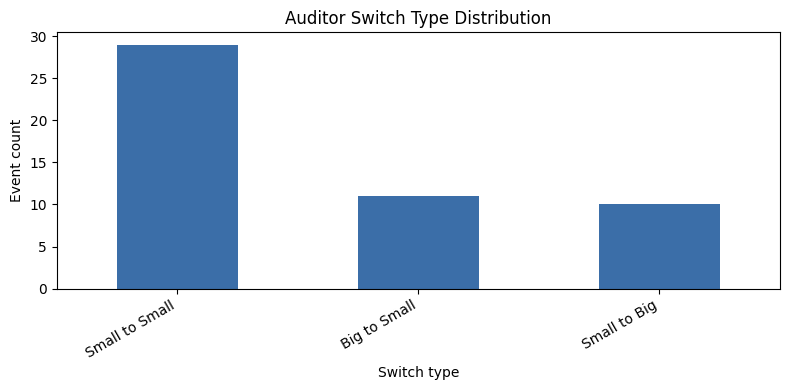

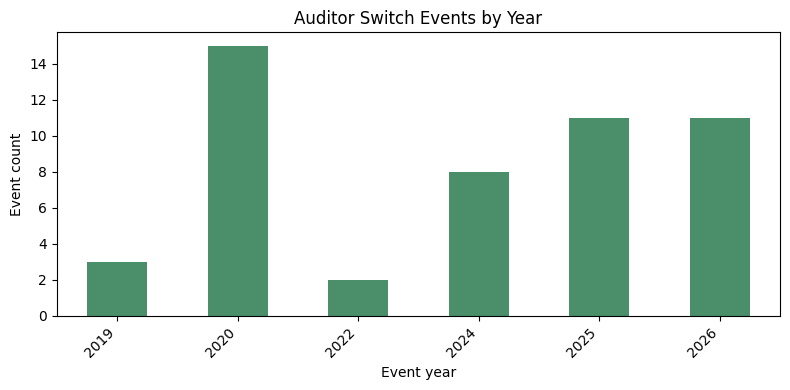

In [39]:
if not switch_type_distribution_df.empty:
    ax = switch_type_distribution_df.plot.bar(x="switch_type", y="event_count", legend=False, figsize=(8, 4), color="#3B6EA8")
    ax.set_title("Auditor Switch Type Distribution")
    ax.set_xlabel("Switch type")
    ax.set_ylabel("Event count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "switch_type_distribution_v01.png", dpi=150)
    plt.show()

if not event_count_by_year_df.empty:
    ax = event_count_by_year_df.plot.bar(x="event_year", y="event_count", legend=False, figsize=(8, 4), color="#4A8F6A")
    ax.set_title("Auditor Switch Events by Year")
    ax.set_xlabel("Event year")
    ax.set_ylabel("Event count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "event_count_by_year_v01.png", dpi=150)
    plt.show()

In [40]:
source_feasibility_df

,source_name,intended_use,access_method,requires_authentication,likely_free,suitable_for_historical_prices,suitable_for_event_validation,stability_level,legal_or_terms_risk,notes
0,Google Finance / Google Sheets GOOGLEFINANCE,Historical stock prices and historical index p...,Manual or semi-automatic Google Sheets GOOGLEF...,No for manual Google Sheets use; yes if automa...,True,Potentially suitable after symbol verification,Limited,Medium,Low if used through Google Sheets formulas; av...,No standard public Python API. Notebook 01 cre...
1,Investing.com,Fallback for historical prices and market pages,Manual lookup or very limited accessibility ch...,Usually no for public pages; restrictions may ...,True,Possible but fragile,Moderate,Low,Medium to high for scraping; terms and anti-bo...,Do not use aggressive scraping. Treat as fallb...
2,Bizportal,Israeli market data and financial news reference,Manual lookup; limited public-page checks,Unknown,True,Unclear,Moderate,Low to medium,Medium for scraping,"Likely useful for local market context, but no..."
3,Globes,News/context around auditor events,Manual lookup; limited public-page checks,Some content may require subscription,Partly,No,High,Medium,Medium for scraping; low for citation/manual c...,More appropriate for event validation and cont...
4,Maya / TASE,"Official disclosures, company reporting, ident...",Official website/manual lookup; API availabili...,Possibly for structured or bulk access,Partly,Unclear; may be restricted or paid,High,High for official disclosures; unknown for pro...,Low to medium if terms are respected,Promising for official identifiers and event v...


In [41]:
connectivity_report_df

,source_name,test_url,http_status_code,accessible_boolean,error_message,tested_at
0,Google Finance,https://www.google.com/finance/,200,True,,2026-05-27T10:53:06.181172+00:00
1,Investing.com,https://www.investing.com/,200,True,,2026-05-27T10:53:07.246029+00:00
2,Bizportal,https://www.bizportal.co.il/,200,True,,2026-05-27T10:53:08.296093+00:00
3,Globes,https://www.globes.co.il/,200,True,,2026-05-27T10:53:08.706261+00:00
4,Maya / TASE,https://maya.tase.co.il/,200,True,,2026-05-27T10:53:09.117052+00:00


## 15. Validation Checks

These checks verify the structural assumptions needed by later notebooks and the future Streamlit dashboard. Ordinary data-quality issues remain row-level flags, but missing dashboard-ready columns or silent row loss should stop the notebook with a clear error.

In [42]:
required_dashboard_columns = [
    "company_name",
    "event_date",
    "auditor_switch_date",
    "report_publication_date",
    "event_date_basis",
    "event_is_future",
    "price_extraction_eligibility",
    "reported_stock_change_raw",
    "reported_stock_change",
    "implied_return",
    "reported_vs_implied_diff",
    "price_consistency_flag",
]
missing_required_columns = [column for column in required_dashboard_columns if column not in cleaned_events_df.columns]
if missing_required_columns:
    raise ValueError(f"Required dashboard-ready columns are missing: {missing_required_columns}")

if len(cleaned_events_df) != len(raw_events_df):
    raise ValueError(f"Row count changed during cleaning: raw={len(raw_events_df)}, clean={len(cleaned_events_df)}")

if len(raw_events_df) == 50 and len(cleaned_events_df) != 50:
    raise ValueError("Expected 50 rows for the current raw workbook, but the cleaned dataset has a different row count.")
elif len(raw_events_df) != 50:
    warnings.warn(f"Raw workbook row count is {len(raw_events_df)}, not 50; validation uses the current raw row count instead.")

if "event_date" not in cleaned_events_df.columns or "company_name" not in cleaned_events_df.columns:
    raise ValueError("The cleaned dataset must contain event_date and company_name.")

raw_has_reported_change = any(_normalized_label(column) == "שינוי באחוזים" for column in raw_events_df.columns)
if raw_has_reported_change and cleaned_events_df["reported_stock_change_raw"].isna().all():
    raise ValueError("The raw workbook contains שינוי באחוזים, but reported_stock_change_raw is entirely missing.")

if "price_extraction_eligibility" not in cleaned_events_df.columns:
    raise ValueError("price_extraction_eligibility is required for future price extraction planning.")

validation_summary = {
    "raw_rows": int(len(raw_events_df)),
    "clean_rows": int(len(cleaned_events_df)),
    "required_columns_present": len(missing_required_columns) == 0,
    "reported_stock_change_non_missing_rows": int(cleaned_events_df["reported_stock_change_raw"].notna().sum()),
    "future_events": int(cleaned_events_df["event_is_future"].sum()),
}
validation_summary

{'raw_rows': 50,
 'clean_rows': 50,
 'required_columns_present': True,
 'reported_stock_change_non_missing_rows': 23,
 'future_events': 2}

## Notebook 01 Conclusions

The following conclusion cell is generated from the current run so the notebook ending reflects the actual loaded workbook and data-quality state.

In [43]:
from IPython.display import Markdown, display

events_loaded = len(cleaned_events_df)
valid_dates = int(cleaned_events_df["event_date_status"].eq("OK").sum())
future_events = int(cleaned_events_df["event_is_future"].sum())
eligible_price_events = int(cleaned_events_df["price_extraction_eligibility"].eq("ELIGIBLE_FOR_PRICE_EXTRACTION").sum())
companies_need_mapping = int(ticker_mapping_template_df["company_name"].nunique())
google_row = source_feasibility_df[source_feasibility_df["source_name"].str.contains("Google", case=False, na=False)].iloc[0]
official_row = source_feasibility_df[source_feasibility_df["source_name"].str.contains("Maya", case=False, na=False)].iloc[0]

conclusion = f"""
### Notebook 01 Conclusions

- Events loaded: **{events_loaded}**.
- Valid baseline event dates found: **{valid_dates}**.
- Future-dated baseline events: **{future_events}**.
- Events currently eligible for historical price extraction: **{eligible_price_events}**.
- Companies requiring ticker mapping: **{companies_need_mapping}**.
- Preliminary source assessment: Google Sheets `GOOGLEFINANCE` appears promising for historical price templates after symbol verification, while Maya/TASE appears especially important for official identifiers and event validation.
- The cleaned event table is saved with stable dashboard-ready column names under `data/interim/`, and the audit/source reports are saved under `data/output/`.
- Notebook 01 preserves both `auditor_switch_date` and `report_publication_date`; the baseline `event_date` currently uses `auditor_switch_date`.
- Final price extraction is postponed because ticker identifiers, source access, and trading-day windows must be verified before calculating market reaction around the event window.
- Later notebooks should enrich the event table with ticker mapping, historical stock prices, TA-125 prices, event-window prices, stock returns, market returns, and market-adjusted returns.
- The Streamlit dashboard is the final academic deliverable and should load the artifacts generated by these notebooks rather than repeating raw data-cleaning logic inside the app.

These outputs prepare the project for later market-adjusted return analysis and dashboard development, but they are not evidence of causality and do not yet constitute the final event-study calculation.
"""
display(Markdown(conclusion))


### Notebook 01 Conclusions

- Events loaded: **50**.
- Valid baseline event dates found: **50**.
- Future-dated baseline events: **2**.
- Events currently eligible for historical price extraction: **48**.
- Companies requiring ticker mapping: **49**.
- Preliminary source assessment: Google Sheets `GOOGLEFINANCE` appears promising for historical price templates after symbol verification, while Maya/TASE appears especially important for official identifiers and event validation.
- The cleaned event table is saved with stable dashboard-ready column names under `data/interim/`, and the audit/source reports are saved under `data/output/`.
- Notebook 01 preserves both `auditor_switch_date` and `report_publication_date`; the baseline `event_date` currently uses `auditor_switch_date`.
- Final price extraction is postponed because ticker identifiers, source access, and trading-day windows must be verified before calculating market reaction around the event window.
- Later notebooks should enrich the event table with ticker mapping, historical stock prices, TA-125 prices, event-window prices, stock returns, market returns, and market-adjusted returns.
- The Streamlit dashboard is the final academic deliverable and should load the artifacts generated by these notebooks rather than repeating raw data-cleaning logic inside the app.

These outputs prepare the project for later market-adjusted return analysis and dashboard development, but they are not evidence of causality and do not yet constitute the final event-study calculation.
